# **Сборный проект-1. Определение закономерностей успешности игры для магазина компьютерных игр**

**Описание проекта**

Мы работаем в интернет-магазине «Стримчик», который продаёт по всему миру компьютерные игры. Из открытых источников доступны исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, Xbox или PlayStation). Нам нужно выявить определяющие успешность игры закономерности. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

Перед нами данные до 2016 года. Представим, что сейчас декабрь 2016 г., и мы планируем кампанию на 2017-й. Нужно отработать принцип работы с данными.

Необходимо:
1. Провести исследовательский анализ данных 
2. Составить портрет пользователя каждого региона:
  - Самые популярные платформы (топ-5)
  - Самые популярные жанры (топ-5)
  - Влияние рейтинга ESRB на продажи
3. Проверить гипотезы:
  - Средние пользовательские рейтинги платформ Xbox One и PC одинаковые
  - Средние пользовательские рейтинги жанров Action и Sports разные

В наборе данных попадается аббревиатура ESRB (Entertainment Software Rating Board) — это ассоциация, определяющая возрастной рейтинг компьютерных игр. ESRB оценивает игровой контент и присваивает ему подходящую возрастную категорию, например, «Для взрослых», «Для детей младшего возраста» или «Для подростков».

**Описание данных**

•	`Name` — название игры

•	`Platform` — платформа

•	`Year_of_Release` — год выпуска

•	`Genre` — жанр игры

•	`NA_sales` — продажи в Северной Америке (миллионы проданных копий)

•	`EU_sales` — продажи в Европе (миллионы проданных копий)

•	`JP_sales` — продажи в Японии (миллионы проданных копий)

•	`Other_sales` — продажи в других странах (миллионы проданных копий)

•	`Critic_Score` — оценка критиков (максимум 100)

•	`User_Score` — оценка пользователей (максимум 10)

•	`Rating` — рейтинг от организации ESRB (англ. Entertainment Software Rating Board). Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.


## Загрузка данных, изучение общей информации

In [1]:
# импортируем все необходимые для работы библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st

In [2]:
# настраиваем формат вывода вещественных чисел
pd.options.display.float_format ='{:,.2f}'.format

In [3]:
# cохраняем данные из файла в датафрейм data
try:
    data = pd.read_csv('/datasets/games.csv')
except:
    data = pd.read_csv('https://code.s3.yandex.net/datasets/games.csv')

In [4]:
# выводим общую информацию по столбцам датафрейма
data.info()
# выводим первые десять строк, чтобы ознакомиться с данными
data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,"2,006.00",Sports,41.36,28.96,3.77,8.45,76.00,8,E
1,Super Mario Bros.,NES,"1,985.00",Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,"2,008.00",Racing,15.68,12.76,3.79,3.29,82.00,8.3,E
3,Wii Sports Resort,Wii,"2,009.00",Sports,15.61,10.93,3.28,2.95,80.00,8,E
4,Pokemon Red/Pokemon Blue,GB,"1,996.00",Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,"1,989.00",Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,"2,006.00",Platform,11.28,9.14,6.50,2.88,89.00,8.5,E
7,Wii Play,Wii,"2,006.00",Misc,13.96,9.18,2.93,2.84,58.00,6.6,E
8,New Super Mario Bros. Wii,Wii,"2,009.00",Platform,14.44,6.94,4.70,2.24,87.00,8.4,E
9,Duck Hunt,NES,"1,984.00",Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


**Вывод:** 

Выведенная сводная информация по датафрейму и первые десять строк показывают часть проблем, которые предстоит исправить на этапе предобработки (подготоки) данных. Мы видим, что нужно сделать переименование столбцов, так чтобы привести все названия к "змеиному регистру". Затем нужно исправить тип данных по столбцам 'Year_of_Release' и 'User_Score'. Также мы видим, что в датафрейме есть много пропусков, особенно по столбцам 'Critic_Score', 'User_Score' и 'Rating', нужно будет решить, какие из них мы можем заполнить и каким образом, а какие оставить незаполненными.

## Подготовка данных

In [5]:
# приведем названия всех столбцов к нижнему регистру
data.columns =  data.columns.str.lower()

In [6]:
# удалим строки с пропуcками по столбцу с годом релиза игры
data = data.dropna(subset = ['year_of_release']).reset_index(drop = True)
# изменим тип данных в столбце 'year_of_release'
data['year_of_release'] = data['year_of_release'].astype('int', errors = 'raise')

In [7]:
# посмотрим все уникальные значения в столбце 'user_score'
data['user_score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

In [8]:
# посчитаем, как много значений 'tbd' содержится в столбце 'user_score'
data[data['user_score'] == 'tbd']['user_score'].count()

2376

Мы видим, что в 2376 ячейках столбца 'user_score' есть строковое значение 'tbd'. Это сокращение от выражения 'to be determined' = будет определено. Возможно, такое значение оценки связано с новыми играми или играми, по которым ещё очень мало, либо нет оценок, поэтому средняя пользовательская оценка не посчитана. Если оставить строковое значение 'tbd' как есть, то мы не сможем выполнять операции по столбцу с оценками, считать среднюю оценку по какой-либо категории и т.п. Поэтому лучше заменить 'tbd' на пустые значения, тогда будет возможно изменить тип данных в столбце. А часть пустых значений после этого мы попробуем по повзможности заполнить. 

Если посмотреть таблицу, то видно, что оценка пользователей едва ли очень сильно расходится с оценкой критиков (если перевести в одну шкалу). Можно посчитать средние пользовательские оценки для разных категорий, составленных на основе оценок критиков, и те пустые значения пользовательской оценки, для которых оценка критиков имеет непустое значение (следовательно определена категория), заменить на среднее пользовательской оценки для соответсвующей категории. Аналогичную операцию можно проделать по строкам с пустыми значениями в 'critic_score' и непустыми в 'user_score', заменив пустые значения в 'critic_score' на средние оценки критиков по категории, заданной на основе оценки по 'user_score'.

In [9]:
# заменим 'tbd' на пустые значения
data.loc[data['user_score'] == 'tbd', 'user_score'] = np.nan

In [10]:
# изменим тип данных в столбце 'user_score'
data['user_score'] = data['user_score'].astype('float', errors = 'raise')

In [11]:
# выведем общую информацию, чтобы убедиться, что тип данных изменился
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16446 entries, 0 to 16445
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16446 non-null  object 
 2   year_of_release  16446 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16446 non-null  float64
 5   eu_sales         16446 non-null  float64
 6   jp_sales         16446 non-null  float64
 7   other_sales      16446 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           9768 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [12]:
# проверяем как распределяется оценка рейтинга от организации ESRB для игр жанара 'Shooter'
data.query('genre == "Shooter"')['rating'].value_counts()

M       553
T       340
E10+     56
E        47
Name: rating, dtype: int64

В столбце 'rating' также очень много пропусков. Наиболее ожидаемо, что для жанра 'Shooter' есть возрастные ограничения. Однако, хотя большинство игр этого жанра имеют рейтинг 'M', при этом более 40% игр жанра имеют иные рейтинговые оценки. Поэтому присвоить всем шутерам без оценки рейтинг 'M' будет неверным решением. Для игр других жанров мы также едва ли можем верно заполнить пропуски по стобцу рейтинга от организации ESRB. Лучше оставить существующие пропуски незаполненными.

In [13]:
# Проверяем, нет ли в датафрейме повторяющихся строк
print('Число полных дубликатов', data.duplicated().sum())
# Проверяем, нет ли в датафрейме строк c неявными дублями (совпадениями по части столбцов)
print('Число неявных дубликатов', data.duplicated(subset = ['name',
                                                            'platform',
                                                            'year_of_release']).sum())

Число полных дубликатов 0
Число неявных дубликатов 2


In [14]:
# удаляем неявные дубликаты
data = data.drop_duplicates(subset = ['name', 'platform',
                                      'year_of_release']).reset_index(drop = True)
# повторяем проверку дублей
print('Число неявных дубликатов', data.duplicated(subset = ['name',
                                                            'platform',
                                                            'year_of_release']).sum())

Число неявных дубликатов 0


In [15]:
# выводим полную информацию по таблице, чтобы посмотреть число оставшихся пропусков
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16444 entries, 0 to 16443
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16443 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16443 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7982 non-null   float64
 9   user_score       7462 non-null   float64
 10  rating           9767 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [16]:
# добавляем столбец, в который заносим суммарные продажи по всем регионам для каждой строки
data['total_sales'] = data[['na_sales', 'eu_sales',
                            'jp_sales', 'other_sales']].sum(axis=1)
# выводим первые строки таблицы
data.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.00,8.00,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.00,8.30,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.00,8.00,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


**Вывод:**

Мы привели названия всех столбцов к нижнему регистру и изменили тип данных в столбцах 'year_of_release' и 'user_score'.  Строки с пустыми значениями по году релиза игры мы удалили из датафрейма, их не так много (269 из 16715), и для нашего исследования они малоинформативны. После этого тип данных по году релиза игры был изменён на целочисленные значения. Мы также заменили в 2376 ячейках столбца 'user_score' строковое значение 'tbd' (сокр. от 'to be determined' = будет определено) на пустые значения, потому что, если оставить строковое значение 'tbd' как есть, мы не сможем выполнять операции по столбцу с оценками, считать среднюю оценку по какой-либо категории и т.п. Вероятно, значение оценки 'tbd' связано с новыми играми или играми, по которым ещё очень мало, либо нет оценок, так что средняя пользовательская оценка не посчитана.

В датафрейме довольно много пропусков в столбцах 'critic_score' и 'user_score'. Это среднице оценки, которые считаются по множеству отзывов, поэтому адекватно заполнить пропуски здесь без информации по отдельным отзывам не представляется возможным.

Мы проверили возможную взаимосвязь жанра игры и рейтинга от организации ESRB (столбец 'rating'), и выявили, что игры одного жанра, хотя преимущественно могут иметь одну рейтинговую оценку, получают самые разные значения оценки от ESRB. Поэтому заполнить пропуски по столбцу 'rating' не представляется возможным.

В результате выполнения предобработки данных в датафрейме осталось много пропусков по столбцам 'critic_score', 'user_score' и 'rating'. Мы не нашли верного способа заполнить пропуски или часть оставшихся порпусков, поэтому лучше оставить их и продолжить работать с такой таблицей. При этом данные по другим столбцам могут иметь важное значение для исследования, поэтому строки с пропусками не стоит удалять. Отчасти пропуски связаны с тем, что могут отноститься к играм-новинкам, которые ещё не получили своих оценок или рейтинга от организации ESRB, либо к играм с низкой популярностью, о которых редко отзываются критики и пользователи. Также возможно, что по какой-то причине данных об оценках и рейтинге игры не оказалось в открытых источниках, либо эти данные не выгрузились в базу. Рейтинги от ESRB могут отсутствовать, потому что полная экспертиза и присваивание рейтинга очень трудоемкий процесс, возможно, компания прежде всего выставляет рейтинг популярным играм и реже добирается до менее известных.

На последнем этапе подготовки данных мы добавили в датафрейм столбец, в который занесли суммарные продажи по всем регионам для каждой строки. Т.е. таким образом мы получили суммарные продажи по каждой игре в датафрейме.

## Исследовательский анализ данных

In [17]:
# посмотрим, сколько игр выпускалось в разные годы, и выведем список в порядке убывания
data['year_of_release'].value_counts()

2008    1427
2009    1426
2010    1255
2007    1197
2011    1136
2006    1006
2005     939
2002     829
2003     775
2004     762
2012     652
2015     606
2014     581
2013     544
2016     502
2001     482
1998     379
2000     350
1999     338
1997     289
1996     263
1995     219
1994     121
1993      61
1981      46
1992      43
1991      41
1982      36
1986      21
1983      17
1989      17
1990      16
1987      16
1988      15
1985      14
1984      14
1980       9
Name: year_of_release, dtype: int64

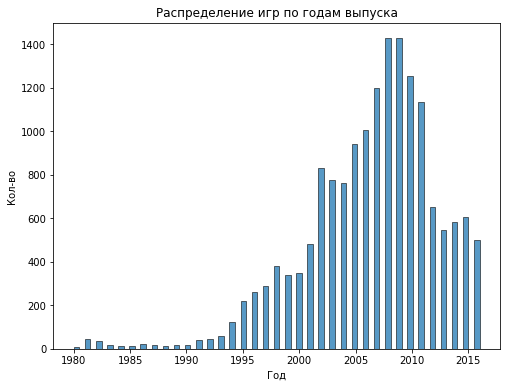

In [18]:
# выводим гистограмму кол-ва игр по годам
plt.figure(figsize = (8, 6))
sns.histplot(data=data, x='year_of_release', bins = 73)
plt.title('Распределение игр по годам выпуска')
plt.xlabel('Год')
plt.ylabel('Кол-во')
plt.show()

**Вывод:** 
Данные показывают, что до 1995 года продажи были на порядок ниже, чем в последующие годы. В последствие продажи достигли пика в 2008-2009 гг., после чего заметно снизились, но не опускались ниже уровня 2001 года.

In [19]:
# теперь выведем сводную таблицу с суммарными продажами по каждой платформе, отсортированную в порядке убывания продаж
platform_sales = data.pivot_table(index = 'platform',
                                  values = 'total_sales',
                                  aggfunc = 'sum').sort_values(by='total_sales',
                                                               ascending = False)
display(platform_sales)

,total_sales
platform,
PS2,"1,233.56"
X360,961.24
PS3,931.33
Wii,891.18
DS,802.78
PS,727.58
PS4,314.14
GBA,312.88
PSP,289.53


In [20]:
# запишем отдельно список наиболее популярных платформ, чтобы можно было к нему обратиться
platform_top = platform_sales.head(6).index.tolist() 
platform_top

['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS']

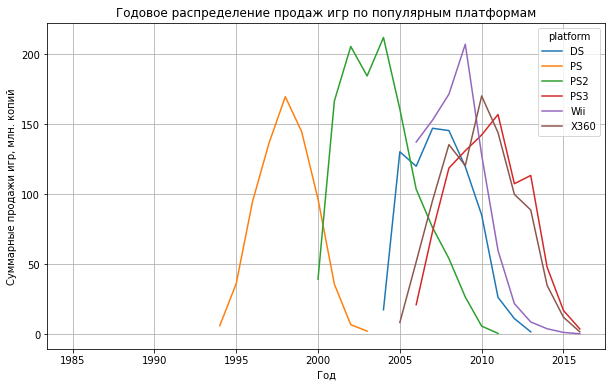

In [21]:
# построим графики годового распределения продаж игр по топ-6 наиболее популярных платформ за всё время
data.query('platform == @platform_top').pivot_table(index = 'year_of_release',
                                                    columns = 'platform',
                                                    values = 'total_sales',
                                                    aggfunc='sum'
                                                   ).plot(figsize = (10, 6),
                                                          grid = True,
                                                          title = 'Годовое распределение продаж игр по популярным платформам',
                                                          xlabel = 'Год',
                                                          ylabel = 'Суммарные продажи игр, млн. копий')
plt.show()

**Вывод:**

Для графиков мы выбрали топ-6 наиболее популярных платформ по кол-ву проднанных копий за всё время. Продажи по выбранным платформам значительно превосходят продажи по платформам, не вошедшим в топ-6. Так например продажи по платформе `PS`, занявшей 6-е место по продажам за всё время (вплоть до конца 2016 года), в 2,3 раза выше продаж по платтформе `PS4`, расположившейся на 7-м месте. Мы видим, что жизненный цикл игровой платформы на примере выбранных топ-6 платформ составляет 10-12 лет. Очевидно, что существуют и более долгоживущие платформы. При этом рост продаж происходит в первые 4-6 лет жизни платформы, а в последующие годы происходит снижение продаж вплоть до значения, стремящегося к нулю, либо закрытия платформы.

Для дальнейшего анализа мы выбрали актуальный период с 2013 по 2016 годы, т.е. не более чем 4-х летний период по отношению к 2017 году, на который нам нужно сделать прогноз и запланировать рекламные кампании. Таким образом мы сможем выделить успешные платформы, которые на 2017 год будут находиться в периоде финального роста или выйдут на плато.

In [22]:
# создаём новый датафрейма по фильтру года релиза игры после 2010 года
actual_data = data.query('year_of_release > 2012').reset_index()
# создаём сводную таблицу по суммарным продажам по платформам за выбранный актуальный период
actual_data.pivot_table(index = 'platform', values = 'total_sales',
                        aggfunc = 'sum').sort_values(by='total_sales', ascending = False)

,total_sales
platform,
PS4,314.14
PS3,181.43
XOne,159.32
3DS,143.25
X360,136.80
WiiU,64.63
PC,39.43
PSV,32.99
Wii,13.66


**Вывод:** Всего 11 платформ отобразились в таблице продаж за 2013-2016 гг. По 4 платформам из списка - `PS3`, `X360`, `Wii`, `DS` - мы уже выводили графики продаж и увидели, что у первых трёх из них продажами стремительно падают на выбранном временном периоде, а платформа `DS` была закрыта в 2013 году. Теперь отобразим на графке продажи вместе по всем платформам, представленным в актуальном периоде.

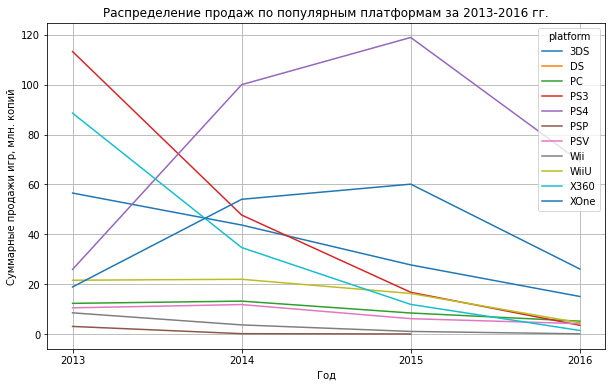

In [23]:
# построим графики годового распределения продаж игр по платформам за 2014-2016 гг.
actual_data.pivot_table(index = 'year_of_release', columns = 'platform',
                        values = 'total_sales', aggfunc='sum'
                       ).plot(figsize = (10, 6),
                              grid = True,
                              title = 'Распределение продаж по популярным платформам за 2013-2016 гг.',
                              xlabel = 'Год',
                              ylabel = 'Суммарные продажи игр, млн. копий')
plt.xticks(np.arange(actual_data['year_of_release'].min(),
                     actual_data['year_of_release'].max()+1, 1))
plt.show()

**Вывод:** 

Продаж по платформе `DS` не видно на графике - мы имеем данные только за 2013 год, т.е. эта платформа закрылась в 2013 году. Судя по графику платформа `PSP` также закрылась в 2015 году. Также продажи игр на платформе `Wii` близки к нулю в 2016 году, и вероятно в 2016 году платформа также закрылась. Мы видим, что продажи игр на платформах `3DS`, `X360` и `PS3` довольно резко идут вниз, вероятно это платформы, чей жизненный цикл закончится в ближайшие 1-2 года после 2016 года. Продажи по платформам `PC`, `WiiU` и `PSV` невысокие и снижаются более плавно (нужно сделать поправку на 2016 год, по которому у нас неполные данные). При детальном рассмотрении становится ясно, что платформа `PC` является примером долгоживущей платформы, которая обычно уступает лидерам, но стабильно находит свою аудиторию. Платформы `WiiU` и `PSV`, вероятно, можно считать нишевыми платформами, которые "не взлетели" и вероятнее в ближайшие годы окончательно пойдут вниз. Одназначно растущими можно считать платформы `PS4` и `XOne`, появившиеся в 2013 году. Здесь не должно смущать падение на графике за 2016 год (это данные за неполный год). За полный 2016 год скорее всего будет рост продаж или показатель не ниже 2015 года. В 2017 году по этим двум платформам можно ожидать либо продолжения роста продаж вплоть до выхода на новую вершину по окончании года, либо выхода на плато на уровне 2016 года или чуть выше.

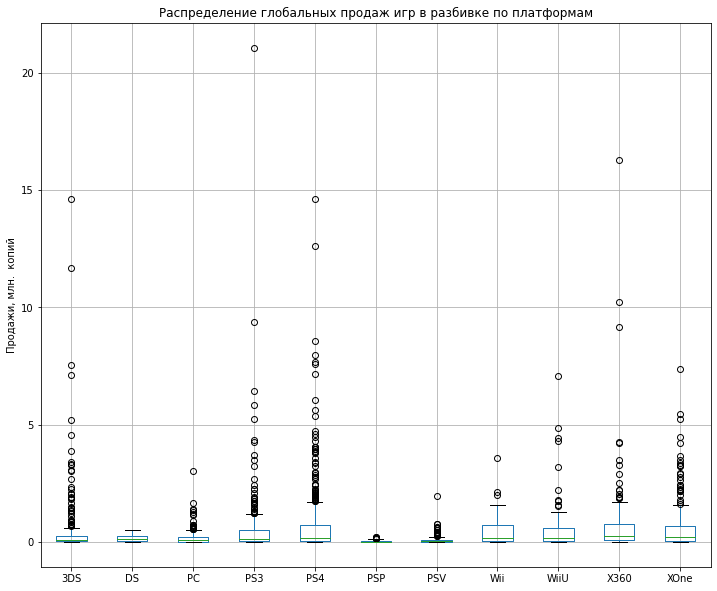

In [24]:
# построим график «ящик с усами» по глобальным продажам игр в разбивке по 8 платформам
actual_data.pivot_table(index = 'name', columns = 'platform',
                        values = 'total_sales', aggfunc='sum'
                       ).plot.box(figsize = (12, 10),
                                  grid=True,
                                  title = 'Распределение глобальных продаж игр в разбивке по платформам',
                                  ylabel = 'Продажи, млн.  копий')
plt.show()

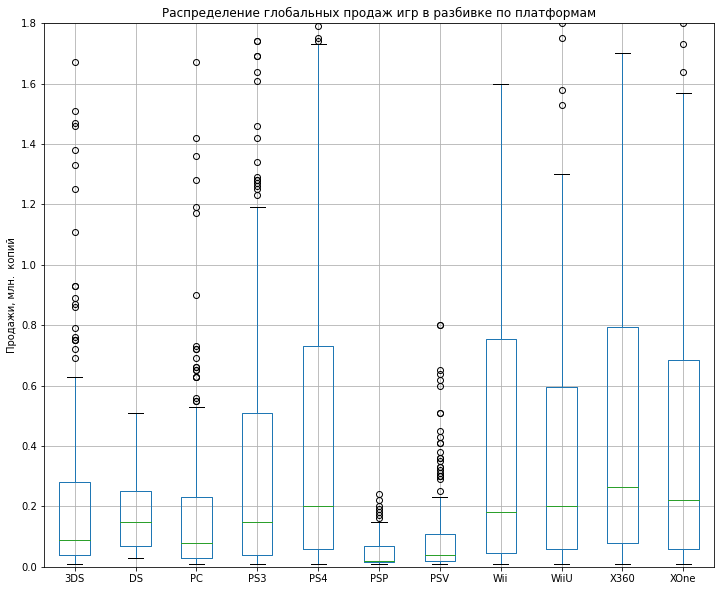

In [25]:
# введём ограничения по оси y, чтобы лучше рассмотреть ящики
actual_data.pivot_table(index = 'name', columns = 'platform',
                        values = 'total_sales', aggfunc='sum'
                       ).plot.box(figsize = (12, 10),
                                  grid=True, title = 'Распределение глобальных продаж игр в разбивке по платформам',
                                  ylabel = 'Продажи, млн.  копий', ylim = (0, 1.8))
plt.show()

**Вывод:** 

Графики «ящик с усами» по глобальным продажам игр по отдельным платформам показывают, что медианное значение продаж для платформы `X360` находится в районе 0,25 млн. копий, для платформ `PS4`, `Wii`, `WiiU`, `XOne` - около 0,2 млн. копий (чуть выше или чуть ниже), для `PS3` и `DS` - около 0,15 млн. копий, а для остальных платформ ограничивается несколькими десятками тысяч. По каждой из платформ продажи для 75% игр (3-й квартиль или верхняя граница ящика на графиках) укладываются в 0,8 млн. проданных копий, а для платформ `3DS`, `DS`, `PC`, `PSP`, `PSV` продажи для 75% игр укладываются в 0,4 млн. проданных копий. Граница продаж в пределах 1,5 квартильного размаха выше третьего квартиля (т.е. в пределах верхнего уса графика) для платформ `PS4`, `Wii`, `X360` и `XOne` находится между 1,4 и 1,8 млн., для `WiiU` и `PS3` - между 1 и 1,4 млн. По остальным платформам граница уса заканчивается ниже 1 млн., для `PSV` немногим выше 0,2 млн. и для `PSP` ниже 0,2 млн. (как мы видели раньше на графике, эта платформа закрылась в 2015 году).

Для каждой платформы на графиках наблюдаются выбросы, лежащие значительно выше "верхнего уса" на графике. Так на платформе `PSV`  продажи одной из игр находятся в районе 2 млн. копий; на платформах `PC`, `Wii` есть хотя бы одна игра, проданная в объеме от 3 до 4 млн. копий.; на платформах `WiiU` и `XOne` есть хотя бы одна игра, проданная в объеме от 7 до 8 млн. копий; на платформах `PS3` и `X360` есть хотя бы одна игра, проданная в объеме близком к 10 млн. копий; на платформах `3DS` и `PS4` хотя бы один из выбросов достигает почти 15 млн. копий, а на платформе `PS3` есть одна игра, проданная в объеме выше 20 млн. копий. 

Выбросы показывают, что продажи игр распределены неравномерно, т.е. большинство игр, вышедших на популярных игровых платформах, имеют "обычную" аудиторию (т.е. в пределах 0,2-0,8 млн.), но время от времени на игровых платформах выходят хиты с огромной аудиторией поклонников по всему миру.

Коэффициент корреляции между оценкой пользователей и продажами на платформе: PS4
             total_sales  user_score
total_sales         1.00       -0.03
user_score         -0.03        1.00 

Коэффициент корреляции между оценкой пользователей и продажами на платформе: PS3
             total_sales  user_score
total_sales         1.00        0.00
user_score          0.00        1.00 

Коэффициент корреляции между оценкой пользователей и продажами на платформе: XOne
             total_sales  user_score
total_sales         1.00       -0.07
user_score         -0.07        1.00 

Коэффициент корреляции между оценкой пользователей и продажами на платформе: X360
             total_sales  user_score
total_sales         1.00       -0.01
user_score         -0.01        1.00 



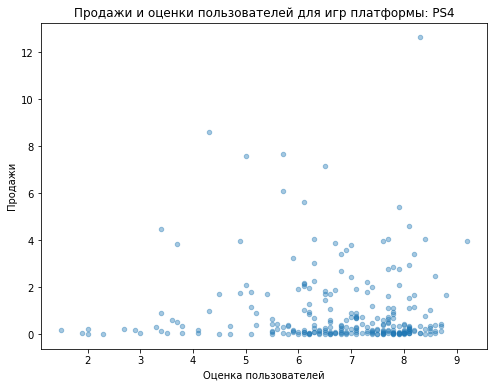

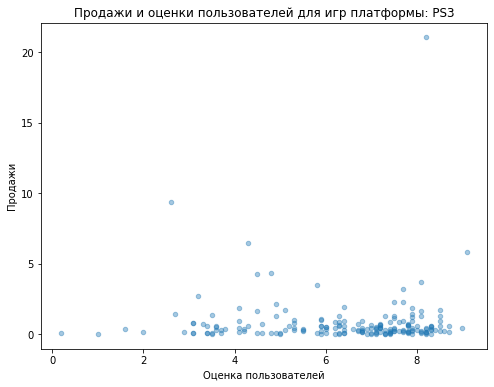

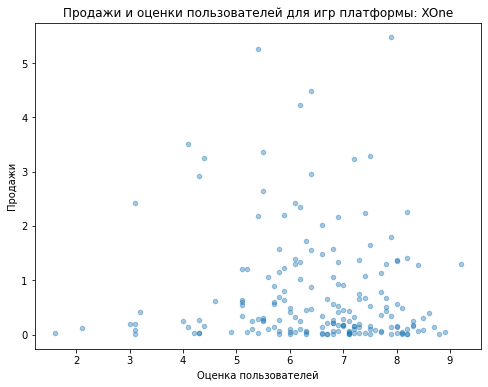

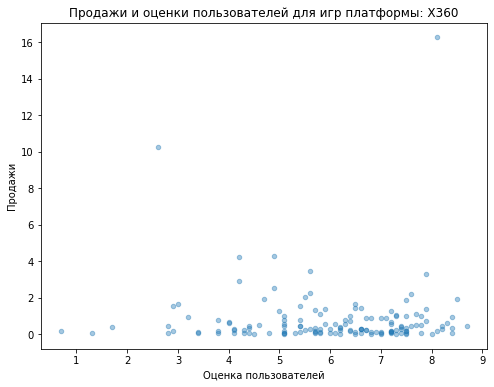

In [26]:
platforms = ['PS4', 'PS3', 'XOne', 'X360']

# построим диаграммы рассеяния для платформ за 2013-2016 гг., чтобы проследить зависимость между продажами и пользовательской оценкой
for i in platforms:
    
    actual_data[actual_data['platform'] == i].pivot_table(
        index = 'name', values = ['total_sales',
                                  'user_score']).plot(x = 'user_score',
                                                      y = 'total_sales',
                                                      kind = 'scatter',
                                                      alpha = 0.4,
                                                      xlabel = 'Оценка пользователей',
                                                      ylabel = 'Продажи',
                                                      title = f'Продажи и оценки пользователей для игр платформы: {i}',
                                                      figsize = (8, 6))
    print(f'Коэффициент корреляции между оценкой пользователей и продажами на платформе: {i}',)
    # посчитаем корреляцию между продажами и пользовательской оценкой
    print(actual_data[actual_data['platform'] == i].pivot_table(
        index = 'name', values = ['total_sales', 'user_score']).corr(), '\n')

Коэффициент корреляции между оценкой пользователей и продажами на платформе: PS4
              critic_score  total_sales
critic_score          1.00         0.41
total_sales           0.41         1.00 

Коэффициент корреляции между оценкой пользователей и продажами на платформе: PS3
              critic_score  total_sales
critic_score          1.00         0.33
total_sales           0.33         1.00 

Коэффициент корреляции между оценкой пользователей и продажами на платформе: XOne
              critic_score  total_sales
critic_score          1.00         0.42
total_sales           0.42         1.00 

Коэффициент корреляции между оценкой пользователей и продажами на платформе: X360
              critic_score  total_sales
critic_score          1.00         0.35
total_sales           0.35         1.00 



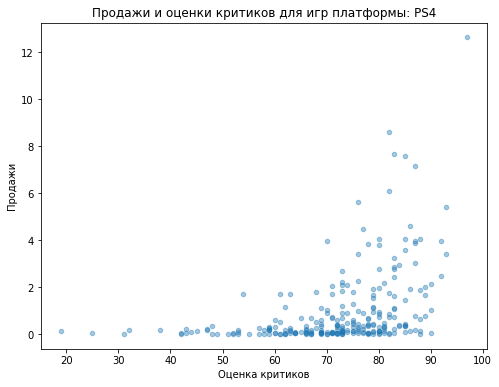

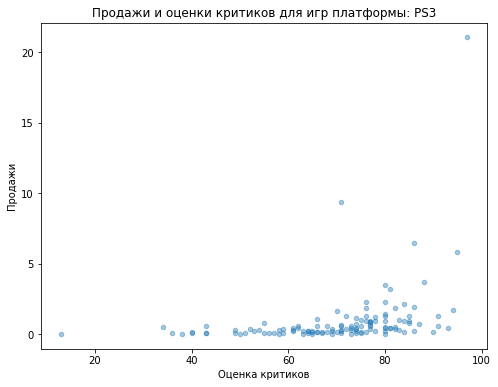

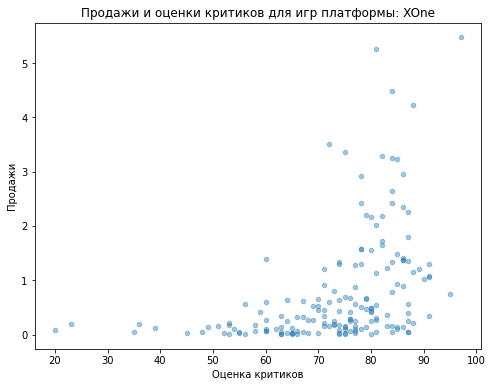

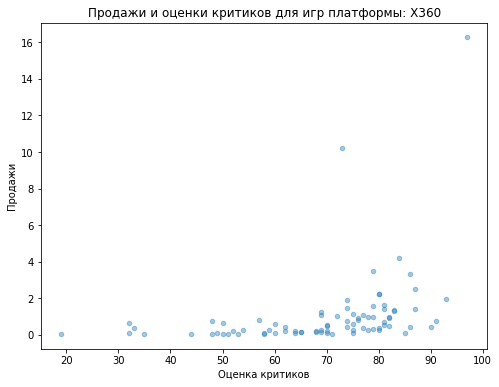

In [27]:
# построим диаграмму размаха для платформ за 2013-2016 гг., чтобы проследить зависимость между продажами и оценкой критиков
for i in platforms:
    actual_data[actual_data['platform'] == i].pivot_table(index = 'name',
                                                          values = ['total_sales',
                                                                    'critic_score']
                                                         ).plot(x = 'critic_score',
                                                                y = 'total_sales',
                                                                kind = 'scatter',
                                                                alpha = 0.4,
                                                                xlabel = 'Оценка критиков',
                                                                ylabel = 'Продажи',
                                                                title = f'Продажи и оценки критиков для игр платформы: {i}',
                                                                figsize = (8, 6))
    # посчитаем корреляцию между продажами и оценкой критиков
    print(f'Коэффициент корреляции между оценкой пользователей и продажами на платформе: {i}')
    print(actual_data[actual_data['platform'] == i].pivot_table(
        index = 'name', values = ['total_sales', 'critic_score']).corr(), '\n')

**Вывод:**

Мы посмотрели на диаграммах размаха связь между продажами и оценками пользователей и критиков по наиболее популярным платформам за 2013-2016 гг. - `PS4`, `PS3`, `XOne`, `X360`. Также мы посчитали коэффициенты корреляции между значениями указанных переменных.

Между продажами и пользовательской оценкой по наиболее популярной платформе `PS4` коэффициент корреляции составляет -0,03. График демонстрирует большой разброс значений продаж независимо от пользовательской оценки. Можно сделать вывод о том, что зависимость между продажами и пользовательской оценкой отсутствует. 

Коэффициент корреляции между продажами и оценкой критиков по платформе `PS4` составляет 0,41. Эта цифра показывает наличие умеренной прямой зависимости между продажами и оценкой критиков. Можно ожидать более высоких продаж для игр с более высокой оценкой. На графике наблюдается большой разброс значений, так что сложно проследить явную зависимость между переменными. Игры с оценками от 35 до 90 могут иметь сравнительно невысокие продажи. Но все же игры с оценками от 85 и выше  гораздо реже продаются плохо. Также игры со сравнительно высокими продажами (выше 1 млн. копий) имеют оценки выше 50, и наконец наиболее успешно продаваемые игры (более 4 млн. копий) имеют оценки выше 70. Можно сделать вывод о том, что существует умеренная прямая зависимость между продажами и пользовательской оценкой. 

Построение диаграмм размаха и подсчёт коэффициентов корреляции для трёх других популярных платформ - `PS3`, `XOne`, `X360` показызывают результаты сопоставимые с данными по платформе `PS4`. Связь между продажами и пользовательской оценкой не прослеживается (коэффициенты корреляции: 0 для `PS3`, -0,07 для `XOne`, -0,01 для `X360`), а между продажами и оценкой критиков подтверждается существование явной умеренной прямой связи (коэффициенты корреляции: 0,33 для `PS3`, 0,42 для `XOne`, 0,35 для `X360`).

In [28]:
# выведем распределение игр по жанрам в порядке убывания
actual_data['genre'].value_counts()

Action          766
Role-Playing    292
Adventure       245
Sports          214
Shooter         187
Misc            155
Racing           85
Fighting         80
Platform         74
Simulation       62
Strategy         56
Puzzle           17
Name: genre, dtype: int64

In [29]:
# выведем таблицу распределения продаж по жанрам, также посчитаем прибыльность одной игры по каждому жанру
# отсортируем в порядке убывания прибыли от жанра
actual_data_genres = actual_data.groupby('genre').agg({'genre': ['count'],
                                                       'total_sales': ['sum']}
                                                     ).reset_index()
actual_data_genres.columns = ('genre', 'genre_count', 'total_sales')
actual_data_genres['average_sales_per_game'] =\
1000*actual_data_genres['total_sales'] / actual_data_genres['genre_count']
actual_data_genres.sort_values(by = 'total_sales',
                               ascending = False).reset_index(drop = True)

,genre,genre_count,total_sales,average_sales_per_game
0,Action,766,321.87,420.20
1,Shooter,187,232.98,"1,245.88"
2,Sports,214,150.65,703.97
3,Role-Playing,292,145.89,499.62
4,Misc,155,62.82,405.29
5,Platform,74,42.63,576.08
6,Racing,85,39.89,469.29
7,Fighting,80,35.31,441.38
8,Adventure,245,23.64,96.49
9,Simulation,62,21.76,350.97


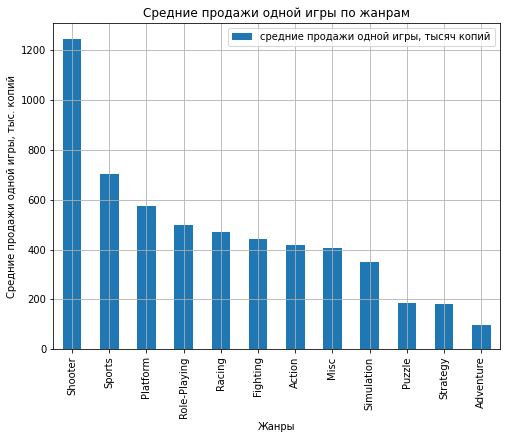

In [30]:
# теперь отсортируем в порядке убывания средней прибыли от продажи одной игры
actual_data_genres.sort_values(by = 'average_sales_per_game',
                               ascending = False
                              ).reset_index(drop = True).plot(kind = 'bar',
                                                              figsize = (8, 6),
                                                              grid = True,
                                                              x = 'genre',
                                                              y = 'average_sales_per_game',
                                                              xlabel = 'Жанры',
                                                              ylabel = 'Средние продажи одной игры, тыс. копий',
                                                              label = 'средние продажи одной игры, тысяч копий',
                                                              title = 'Средние продажи одной игры по жанрам')
plt.show()

**Вывод:**	

За выбранный актуальный период исследования компьютерные игры распределены неравномерно по жанрам. Так, например, игр в жанре `Action` вышло в 2,6 раза больше, чем игр в жанре `Role-Playing`, который занимает второе место по кол-ву игр. Наименее популярный жанр игр - `Puzzle`. Игр в этом жанре выпущено почти в 45 раз меньше, чем игр в жанре `Action`.

Если смотреть на то, какие продажи (в миллионах копий) принес, каждый жанр, то топ-5 жанров за актуальный период в порядке убывания выглядит следующим образом: 

`Action` - 321,9; 

`Shooter` - 233; 

`Sports` - 150,7;

`Role-Playing` - 145,9;  

`Misc` - 62,8.

Самые низкие продажи у игр жанра `Puzzle` - 3,2 млн. копий.

Однако, если говорить о прибыльности, то скорее нужно смотреть средние продажи, которые приносит одна игра в каждом конкретном жанре. Конечно, затраты на разработку игр в разных жанрах могут различаться, но при больших объемах продаж эта разница во многом невелируется. Топ-5 жанров по объёму продаж (тысяч копий), который в среднем приносит одна игра, в порядке убывания выглядит следующим образом:

`Shooter` - 1245,9;

`Sports` - 704;

`Platform` - 576,1;

`Role-Playing` - 499,6;

`Racing` - 469,3.

Самый продуктивный жанр за актуальный период, который в сумме даёт самые большие продажи, по объёму продаж одной игры занимает 7-место с 420,2 тысяч копий. Среди самых неприбыльных жанров выделяется жанр `Adventure` с самым низким показателем - 96,5 тысяч копий.

## Портрет пользователя каждого региона

In [31]:
# сводная таблица по популярности платформ в Северной Америке
na_platforms = actual_data.pivot_table(index = 'platform',
                                       values = 'na_sales',
                                       aggfunc = 'sum'
                                      ).sort_values(by = 'na_sales',
                                                    ascending = False).reset_index()
# добавим в таблицу долю каждой платформы от всех продаж в регионе
na_platforms['share_%'] = 100*(na_platforms['na_sales'] / na_platforms['na_sales'].sum())
# выведем первые 5 строк датафрейма
print("Топ-5 самых популярных платформ в Северной Америке:")
na_platforms.head(5)

Топ-5 самых популярных платформ в Северной Америке:


,platform,na_sales,share_%
0,PS4,108.74,24.84
1,XOne,93.12,21.27
2,X360,81.66,18.66
3,PS3,63.50,14.51
4,3DS,38.20,8.73


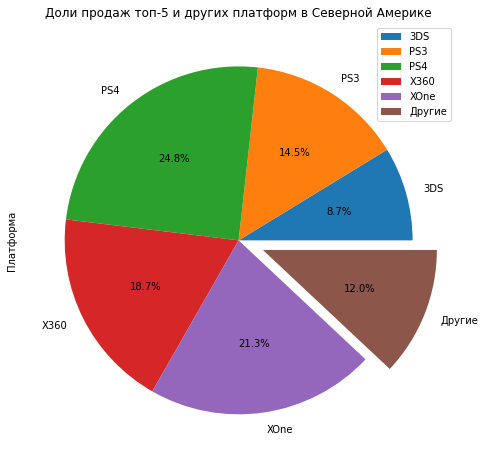

In [32]:
# присвоим платформам, не попавшим в топ-5, название 'Другие'
na_platforms.loc[5:, 'platform'] = 'Другие'
# построим круговую диаграмму по долям продаж топ-5 и другим платформам в регионе
na_platforms.groupby('platform').agg({'share_%': ['sum']}
                                    ).plot(x = 'platform',
                                           y = 'share_%',
                                           figsize = (8, 8),
                                           kind = 'pie',
                                           legend=True,
                                           ylabel = 'Платформа',
                                           autopct='%1.1f%%',
                                           explode = (0, 0, 0, 0, 0, 0.15))  
plt.title('Доли продаж топ-5 и других платформ в Северной Америке')
plt.show()

In [33]:
# сводная таблица по популярности платформ в Европе
eu_platforms = actual_data.pivot_table(index = 'platform',
                                       values = 'eu_sales',
                                       aggfunc = 'sum'
                                      ).sort_values(by = 'eu_sales',
                                                    ascending = False
                                                   ).reset_index()
# добавим в таблицу долю каждой платформы от всех продаж в регионе
eu_platforms['share_%'] = 100*(eu_platforms['eu_sales'] / eu_platforms['eu_sales'].sum())
# выведем первые 5 строк датафрейма
print("Топ-5 самых популярных платформ в Европе:")
eu_platforms.head(5)

Топ-5 самых популярных платформ в Европе:


,platform,eu_sales,share_%
0,PS4,141.09,35.97
1,PS3,67.81,17.29
2,XOne,51.59,13.15
3,X360,42.52,10.84
4,3DS,30.96,7.89


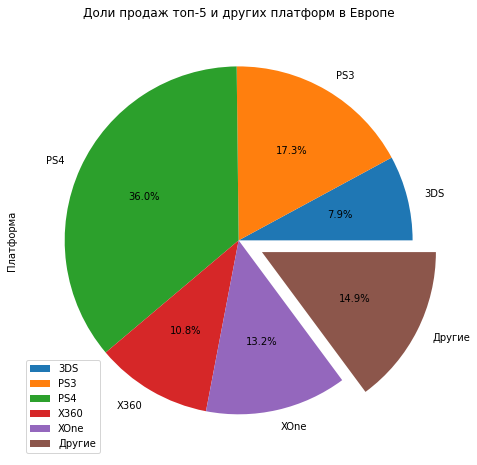

In [34]:
# присвоим платформам, не попавшим в топ-5, название 'Другие'
eu_platforms.loc[5:, 'platform'] = 'Другие'
# построим круговую диаграмму по долям продаж топ-5 и другим платформам в регионе
eu_platforms.groupby('platform').agg({'share_%': ['sum']}
                                    ).plot(x = 'platform',
                                           y = 'share_%',
                                           figsize = (8, 8),
                                           kind = 'pie',
                                           legend=True,
                                           ylabel = 'Платформа',
                                           autopct='%1.1f%%',
                                           explode = (0, 0, 0, 0, 0, 0.15))  
plt.title('Доли продаж топ-5 и других платформ в Европе')
plt.show()

In [35]:
# сводная таблица по популярности платформ в Японии
jp_platforms = actual_data.pivot_table(index = 'platform',
                                       values = 'jp_sales',
                                       aggfunc = 'sum'
                                      ).sort_values(by = 'jp_sales',
                                                    ascending = False
                                                   ).reset_index()
# добавим в таблицу долю каждой платформы от всех продаж в регионе
jp_platforms['share_%'] = 100*(jp_platforms['jp_sales'] / jp_platforms['jp_sales'].sum())
# выведем первые 5 строк датафрейма
print("Топ-5 самых популярных платформ в Японии:")
jp_platforms.head(5)

Топ-5 самых популярных платформ в Японии:


,platform,jp_sales,share_%
0,3DS,67.81,48.17
1,PS3,23.35,16.59
2,PSV,18.59,13.21
3,PS4,15.96,11.34
4,WiiU,10.88,7.73


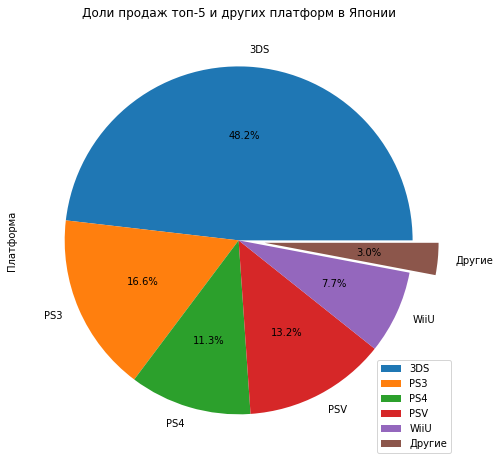

In [36]:
# присвоим платформам, не попавшим в топ-5, название 'Другие'
jp_platforms.loc[5:, 'platform'] = 'Другие'
# построим круговую диаграмму по долям продаж топ-5 и другим платформам в регионе
jp_platforms.groupby('platform').agg({'share_%': ['sum']}
                                    ).plot(x = 'platform',
                                           y = 'share_%',
                                           figsize = (8, 8),
                                           kind = 'pie',
                                           legend=True,
                                           ylabel = 'Платформа',
                                           autopct='%1.1f%%',
                                           explode = (0, 0, 0, 0, 0, 0.15))  
plt.title('Доли продаж топ-5 и других платформ в Японии')
plt.show()

**Вывод:** 

Популярность платформ по регионам имеет различия, при этом между Северной Америкой и Европой отличия не такие большие, как между Японией и Европой или Японией и Северной Америкой. Топ-5 плтаформ в Северной Америке занимают 88% рынка, в Европе топ-5 платформ занимают 85,1% рынка, а в Японии - 97% рынка. Списки топ-5 платформ по Европе и Северной Америке совпадают по названиям платформ, отличия - в расстановке мест и долях продаж.

В Северной Америке первое место занимает платформа `PS4` c 24,8% рынка, второе место - `XOne` с 21,3% рынка, третье место - `X360` с 18,7% рынка. В Европе первое место занимает платформа `PS4` c 36% рынка, второе место - `PS3` с 17,3% рынка, третье место - `XOne` c 10,8% рынка. Платформы `XOne` и `X360` наиболее популярны в Северной Америке, в сумме их доля составляет 40%. Платформа `3DS` занимает 5-е место и в Европе и в Северной Америке с долями ниже 8 и 9 % соответственно.

В Японии же платформа `3DS` занимает первое место с огромным перевесом - 48,2% рынка, т.е. платформа занимает почти половину рынка. На втором месте в Японии - платформа `PS3` с 16,6% рынка, на третьем месте - платформа `PSV` c 13,2% рынка. Платформа `PSV` не входит в топ-5 платформ ни в Европе, ни в Северной Америке. Кроме того в Японии в топ-5 входит платформы `WiiU`, которой нет в топ-5 по Севереной Америке и Европе. В отличие от Европы и Северной Америки, в Японии не попали в топ-5 платформы - `XOne` и `X360`, которые входят в топ-5 других регионов и особенно популярны в Северной Америке.

In [37]:
# сводная таблица по популярности жанров в Северной Америке
na_genres = actual_data.pivot_table(index = 'genre',
                                    values = 'na_sales',
                                    aggfunc = 'sum'
                                   ).sort_values(by = 'na_sales',
                                                 ascending = False).reset_index()
# добавим в таблицу долю продаж по каждому жанру от всех продаж в регионе
na_genres['share_%'] = 100*(na_genres['na_sales'] / na_genres['na_sales'].sum())
# выведем первые 5 строк датафрейма - топ-5 самых популярных жанров в регионе
print('Топ-5 самых популярных жанров в Северной Америке:')
na_genres.head(5) 

Топ-5 самых популярных жанров в Северной Америке:


,genre,na_sales,share_%
0,Action,126.05,28.80
1,Shooter,109.74,25.07
2,Sports,65.27,14.91
3,Role-Playing,46.40,10.60
4,Misc,27.49,6.28


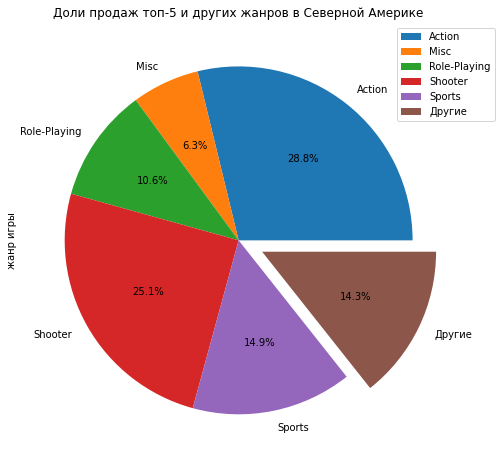

In [38]:
# присвоим жанрам игр, не попавшим в топ-5, название 'Другие'
na_genres.loc[5:, 'genre'] = 'Другие'
# построим круговую диаграмму по долям продаж топ-5 и другим жанрам в регионе 
na_genres.groupby('genre').agg({'share_%': ['sum']}
                              ).plot(x = 'genre',
                                     y = 'share_%',
                                     figsize = (8, 8),
                                     kind = 'pie',
                                     legend=True,
                                     ylabel = 'жанр игры',
                                     autopct='%1.1f%%',
                                     explode = (0, 0, 0, 0, 0, 0.15)) 
plt.title('Доли продаж топ-5 и других жанров в Северной Америке')
plt.legend(bbox_to_anchor = (1.1, 1), loc = 'upper right')
plt.show()

In [39]:
# сводная таблица по популярности жанров в Европе
eu_genres = actual_data.pivot_table(index = 'genre',
                                    values = 'eu_sales',
                                    aggfunc = 'sum'
                                   ).sort_values(by = 'eu_sales',
                                                 ascending = False).reset_index()
# добавим в таблицу долю продаж по каждому жанру от всех продаж в регионе
eu_genres['share_%'] = 100*(eu_genres['eu_sales'] / eu_genres['eu_sales'].sum())
# выведем первые 5 строк датафрейма - топ-5 самых популярных жанров в регионе
print('Топ-5 самых популярных жанров в Европе:')
display(eu_genres.head(5))

Топ-5 самых популярных жанров в Европе:


,genre,eu_sales,share_%
0,Action,118.13,30.12
1,Shooter,87.86,22.40
2,Sports,60.52,15.43
3,Role-Playing,36.97,9.43
4,Racing,20.19,5.15


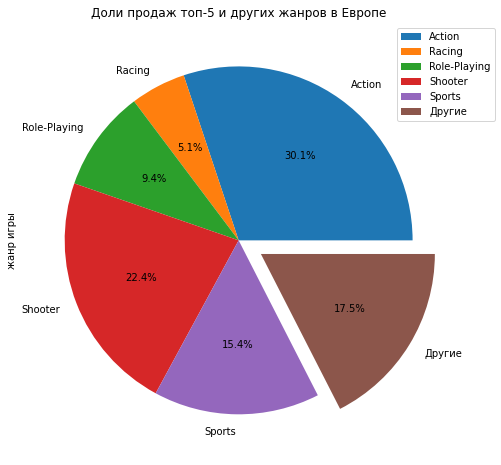

In [40]:
eu_genres.loc[5:, 'genre'] = 'Другие' # присвоим жанрам игр, не попавшим в топ-5, название 'Другие'
# построим круговую диаграмму по долям продаж топ-5 и другим жанрам игр в регионе 
eu_genres.groupby('genre').agg({'share_%': ['sum']}
                              ).plot(x = 'genre',
                                     y = 'share_%',
                                     figsize = (8, 8),
                                     kind = 'pie',
                                     legend=True,
                                     ylabel = 'жанр игры',
                                     autopct='%1.1f%%',
                                     explode = (0, 0, 0, 0, 0, 0.15)) 
plt.title('Доли продаж топ-5 и других жанров в Европе')
plt.legend(bbox_to_anchor = (1.1, 1), loc = 'upper right')
plt.show()

In [41]:
# сводная таблица по популярности жанров в Японии
jp_genres = actual_data.pivot_table(index = 'genre',
                                    values = 'jp_sales',
                                    aggfunc = 'sum'
                                   ).sort_values(by = 'jp_sales',
                                                 ascending = False).reset_index()
# добавим в таблицу долю продаж по каждому жанру от всех продаж в регионе
jp_genres['share_%'] = 100*(jp_genres['jp_sales'] / jp_genres['jp_sales'].sum())
# выведем первые 5 строк датафрейма - топ-5 самых популярных жанров в регионе
print('Топ-5 самых популярных жанров в Японии:')
jp_genres.head(5)

Топ-5 самых популярных жанров в Японии:


,genre,jp_sales,share_%
0,Role-Playing,51.04,36.26
1,Action,40.49,28.76
2,Misc,9.20,6.54
3,Fighting,7.65,5.43
4,Shooter,6.61,4.70


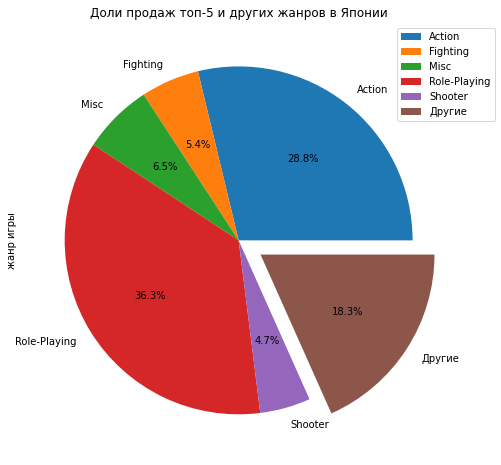

In [42]:
# присвоим жанрам игр, не попавшим в топ-5, название 'Другие'
jp_genres.loc[5:, 'genre'] = 'Другие'
# построим круговую диаграмму по долям продаж топ-5 и другим жанрам игр в регионе
jp_genres.groupby('genre').agg({'share_%': ['sum']}
                              ).plot(x = 'genre',
                                     y = 'share_%',
                                     figsize = (8, 8),
                                     kind = 'pie',
                                     legend=True,
                                     ylabel = 'жанр игры',
                                     autopct='%1.1f%%',
                                     explode = (0, 0, 0, 0, 0, 0.15))  
plt.title('Доли продаж топ-5 и других жанров в Японии')
plt.legend(bbox_to_anchor = (1.1, 1), loc = 'upper right')
plt.show()

**Вывод:**

Мы видим совсем незначительные отличия в топ-5 самых популярных жанров по Северной Америке и Европе. Первые 4 строчки в обоих рейтингах занимают жанры `Action`, `Shooter`, `Sports` и `Role-Playing`. При этом указанные жанры занимают одинаковые 1-4 места, но есть незначительные отличия в долях рынка, которые занимают жанры. Жанры `Action` и`Shooter` в обоих регионах суммарно имеют долю продаж более 50%, а по отдельности доля каждого жанра первышает 20%. На 5-м месте в Северной Америке находится жанр `Misc`, а на 5-м месте в Европе - жанр `Racing`. 

Топ-5 жанров в Севереной Америке вместе составляют 85,7% рынка, топ-5 жанров в Европе - 82,5% рынка, а топ-5 жанров Японии - 81,7%. 

Япония в свою очередь заметно отличается от Европы и Севереной Америки по топ-5 игровых жанров. Жанр `Sports` не входит в топ-5 жанров в Японии, а жанр `Shooter` занимает 5-е место с довольно низкой (по сравнению с 22,4% в Европе и 25,1% в Северной Америке) - 4,7%. Топ-5 жанров в Японии: `Role-Playing`, `Action`, `Misc`, `Fighting` и `Shooter`. Первые два жанра в рейтинге топ-5 - `Role-Playing` и `Action` - в сумме составляют 65,1% рынка. Самый популярный жанр в Японии `Role-Playing` занимает 36,3% рынка, тогда как в Европе доля этого жанра ниже 10%, а в Северной Америке немногим выше 10%. В абсолютном выражении продажи игр жанра `Role-Playing` в Японии также превосходят продажи в двух других регионах.

In [43]:
# заменим пустые значения рейтинга в датафрейме на 'unrated', чтобы учесть их исследовании по рейтингам
actual_data['rating'].fillna('Unrated', inplace = True)
# сводная таблица по популярности игр в разрезе по рейтингам в Северной Америке
na_rating = actual_data.pivot_table(index = 'rating',
                                    values = 'na_sales',
                                    aggfunc = 'sum'
                                   ).sort_values(by = 'na_sales',
                                                 ascending = False).reset_index()
# добавим в таблицу долю продаж по каждому рейтингу ESRB в регионе
na_rating['share_%'] = 100*(na_rating['na_sales'] / na_rating['na_sales'].sum())
# выведем на экран датафрейм целиком
print('Рейтинги ESRB по убыванию популярности в Северной Америке:')
na_rating

Рейтинги ESRB по убыванию популярности в Северной Америке:


,rating,na_sales,share_%
0,M,165.21,37.74
1,Unrated,89.42,20.43
2,E,79.05,18.06
3,E10+,54.24,12.39
4,T,49.79,11.38


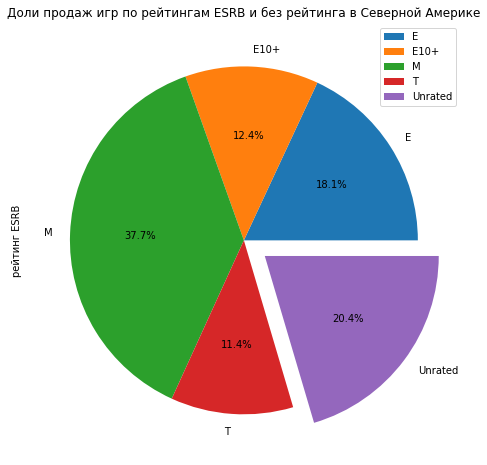

In [44]:
# построим круговую диаграмму по долям продаж топ-5 и другим жанрам в регионе 
na_rating.groupby('rating').agg({'share_%': ['sum']}
                               ).plot(x = 'rating',
                                      y = 'share_%',
                                      figsize = (8, 8),
                                      kind = 'pie',
                                      legend=True,
                                      ylabel = 'рейтинг ESRB',
                                      autopct='%1.1f%%',
                                      explode = (0, 0, 0, 0, 0.15)) 
plt.title('Доли продаж игр по рейтингам ESRB и без рейтинга в Северной Америке')
plt.show()

In [45]:
# сводная таблица по популярности игр в разрезе по рейтингам в Европе
eu_rating = actual_data.pivot_table(index = 'rating',
                                    values = 'eu_sales',
                                    aggfunc = 'sum'
                                   ).sort_values(by = 'eu_sales',
                                                 ascending = False).reset_index()
# добавим в таблицу долю продаж по каждому рейтингу ESRB в регионе
eu_rating['share_%'] = 100*(eu_rating['eu_sales'] / eu_rating['eu_sales'].sum())
# выведем на экран датафрейм целиком
print('Рейтинги ESRB по убыванию популярности в Европе:')
eu_rating

Рейтинги ESRB по убыванию популярности в Европе:


,rating,eu_sales,share_%
0,M,145.32,37.05
1,E,83.36,21.25
2,Unrated,78.91,20.12
3,E10+,42.69,10.88
4,T,41.95,10.70


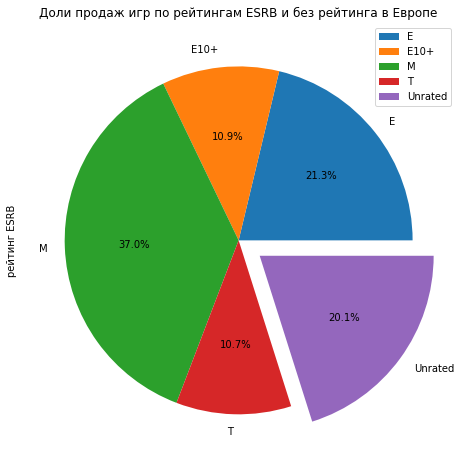

In [46]:
# построим круговую диаграмму по долям продаж топ-5 и другим жанрам в регионе  
eu_rating.groupby('rating').agg({'share_%': ['sum']}
                               ).plot(x = 'rating',
                                      y = 'share_%',
                                      figsize = (8, 8),
                                      kind = 'pie',
                                      legend=True,
                                      ylabel = 'рейтинг ESRB',
                                      autopct='%1.1f%%',
                                      explode = (0, 0, 0, 0, 0.15))
plt.title('Доли продаж игр по рейтингам ESRB и без рейтинга в Европе')
plt.show()

In [47]:
# сводная таблица по популярности игр в разрезе по рейтингам в Японии
jp_rating = actual_data.pivot_table(index = 'rating',
                                    values = 'jp_sales',
                                    aggfunc = 'sum'
                                   ).sort_values(by = 'jp_sales',
                                                 ascending = False).reset_index()
# добавим в таблицу долю продаж по каждому рейтингу ESRB в регионе
jp_rating['share_%'] = 100*(jp_rating['jp_sales'] / jp_rating['jp_sales'].sum())
print('Рейтинги ESRB по убыванию популярности в Японии:')
jp_rating # выведем на экран датафрейм целиком

Рейтинги ESRB по убыванию популярности в Японии:


,rating,jp_sales,share_%
0,Unrated,85.05,60.41
1,T,20.59,14.63
2,E,15.14,10.75
3,M,14.11,10.02
4,E10+,5.89,4.18


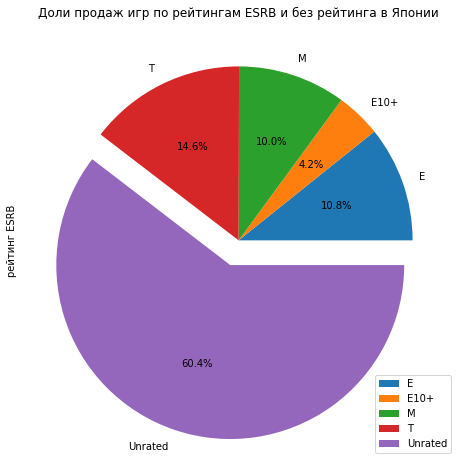

In [48]:
# построим круговую диаграмму по долям продаж топ-5 и другим жанрам в регионе
jp_rating.groupby('rating').agg({'share_%': ['sum']}
                               ).plot(x = 'rating',
                                      y = 'share_%',
                                      figsize = (8, 8),
                                      kind = 'pie',
                                      legend=True,
                                      ylabel = 'рейтинг ESRB',
                                      autopct='%1.1f%%',
                                      explode = (0, 0, 0, 0, 0.15))
plt.title('Доли продаж игр по рейтингам ESRB и без рейтинга в Японии')

plt.legend(loc = 'lower right')
plt.show()

**Вывод:**

Мы заменили пустые значения в столбце `rating` на значение 'unrated' - т.е. буквально 'без рейтинга'. Такая замена позволит нам увидеть долю игр без рейтинга по каждому региону.

В Европе и Северной Америке продажи в зависимости от рейтинга игр мало отличаются между собой. В Северной Америке и Европе наибольшие продажи имеют игры с рейтингом `M` (для взрослых): игры с рейтингом `M` составляют в Северной Америке 37,7% всех продаж, а в Европе - 37% всех продаж. Доля продаж игр без рейтинга в Северной Америке - 20,4%, а в Европе - 20,1%. На основе данных по Европе и Северной Америке сложно заметить, что рейтинг ESRB оказывает заметное влияние на продажи в указанных регионах, но в то же время доля продаж игр без рейтинга сравнительно невелика. 

Более полную картину мы получили после просмотра данных по Япониии, где как и ранее проявились отличия от Европы и Северной Америки. В Японии игры с рейтингом `M` занимают только 4-е место с 10% рынка, тогда как первое место за играми без рейтинга аж с 60,4%, а второе место за играми с рейтингом `T` (для подростков от 13 лет) - 14,6% рынка. Такимм образом, в Японии очень большая доля рынка приходится на игры без рейтинга. В таком случае мы можем сделать вывод, что рейтинг ESRB скорее оказывает влияние на продажи, игры без рейтинга покупаются сравнительно редко, а в Японии похоже рейтинговая ситема ESRB просто не работает, поэтому игры покупают независимо от рейтинга. По всей видимости игры без рейтинга легче достигают своего покупателя в Японии независимо от возраста и в том числе покупателя до 17 лет, поэтому пользуются повышенным спросом. Также есть вероятность, что в Японии взрослые реже играют в компьютерные игры по сравнению с Европой и Северной Америкой (на это указывает низкие продажи игр с рейтингом `M`).

## Проверка гипотез

**Проверка гипотезы о том, что средние пользовательские рейтинги платформ Xbox One и PC одинаковые.**

Сформулируем гипортезы (нулевую и альтернативную) следующим образом:

H₀: μ1 = μ2

H1: μ1 != μ2

где μ1 - истинное среднее пользовательского рейтинга генеральной совокупности пользовательских рейтингов для игр платформы XOne, а μ2 - истинное среднее пользовательского рейтинга генеральной совокупности пользовательских рейтингов для игр платформы PC.

По нулевой гипотезе проверяется равенство истинных средних двух генеральных совокупностей для двух независимых выборок. Если значение pvalue меньше принятого порогового уровня значимости, это будет значить, что наблюдаемое значение слишком далеко от предполагаемого в нулевой гипотезе. В таком случае мы отвергнем нулевую гипотезу в пользу двусторонней альтенативной гипотезы (о неравенстве средних двух генеральных совокупностей). Если же pvalue превысит принятый уровень значимости, то мы не сможем отвергнуть нулевую гипотезу. 

В качестве альтернативной гипотезы мы выбрали двустороннюю гипотезу, т.к. нам не нужно отвечать на вопрос, больше или меньше среднее по какой-то из платформ по сравнению со средним по другой платформе, а только проверить, равны ли они друг другу (нулевая гипотеза), либо не равны. 

In [49]:
# выборка пользовательских оценок по играм на платформе XOne, очищенная от пустых значений
user_score_1 = actual_data.query('platform == "XOne"')['user_score'].dropna()
# выборка пользовательских оценок по играм на платформе PC, очищенная от пустых значений
user_score_2 = actual_data.query('platform == "PC"')['user_score'].dropna()

print('Средняя пользовательская оценка для игр платформы XOne:',
      user_score_1.mean())
print('Средняя пользовательская оценка для игр платформы PC:',
      user_score_2.mean())

# задали уровень значимости
alpha = 0.05
# создаем тест для проверки гипотезы о том, что cредние пользовательские рейтинги платформ Xbox One и PC одинаковые
results = st.ttest_ind(user_score_1, user_score_2, alternative = 'two-sided')

print('p-значение:', results.pvalue)
# сравниваем p-value с уровнем значимости
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')


Средняя пользовательская оценка для игр платформы XOne: 6.521428571428572
Средняя пользовательская оценка для игр платформы PC: 6.2696774193548395
p-значение: 0.14012658403611647
Не получилось отвергнуть нулевую гипотезу


**Вывод:**  Мы не смогли отвергнуть нулевую гипотезу при выбранном уровне значимости 0.05 (гипотеза не была бы отвергнута и при уровне значимости 0.01). Поскольку мы не можем отвергнуть нулевую гипотезу, то с большой долей вероятности средние пользовательские рейтинги платформ Xbox One и PC не имеют статистически значимых отличий.

По выборочным данным мы получили среднюю пользовательскую оценку для для игр платформы XOne - 6.52, тогда как для игр платформы PC средняя пользовательская оценка равна 6.46.

**Проверка гипотезы о том, что средние пользовательские рейтинги жанров Action и Sports разные.**

Сформулируем гипортезы (нулевую и альтернативную) следующим образом:

H₀: μ1 = μ2

H1: μ1 != μ2

где μ1 - истинное среднее пользовательского рейтинга генеральной совокупности пользовательских рейтингов для игр жанра Action, а μ2 - истинное среднее пользовательского рейтинга генеральной совокупности пользовательских рейтингов для игр жанра Sports.

По нулевой гипотезе проверяется равенство истинных средних двух генеральных совокупностей для двух независимых выборок пользовательских рейтингов по жанрам Action и Sports. Если значение pvalue меньше принятого порогового уровня значимости, это будет значить, что наблюдаемое значение слишком далеко от предполагаемого в нулевой гипотезе. В таком случае мы отвергнем нулевую гипотезу в пользу двусторонней альтернативной гипотезы (о неравенстве средних двух генеральных совокупностей). Если же pvalue превысит принятый уровень значимости, то мы не сможем отвергнуть нулевую гипотезу. 

В нашей задаче разность средних пользовательских рейтингов жанров Action и Sports подтвердится в случае отвержения нулевой гипотезы о равенстве средних в пользу альтернативной. 

In [50]:
# выборка пользовательских оценок по играм на платформе XOne, очищенная от пустых значений
action_user_score = actual_data.query('genre == "Action"')['user_score'].dropna()
# выборка пользовательских оценок по играм на платформе PC, очищенная от пустых значений
sports_user_score = actual_data.query('genre == "Sports"')['user_score'].dropna() 

print('Средняя пользовательская оценка для игр жанра Action:',
      action_user_score.mean())
print('Средняя пользовательская оценка для игр жанра Sports:',
      sports_user_score.mean())

alpha = 0.05 # задали уровень значимости
# создаем тест для проверки гипотезы о том, что cредние пользовательские рейтинги жанров Action и Sports разные
results_2 = st.ttest_ind(action_user_score, sports_user_score,
                         alternative = 'two-sided')

print('p-значение:', results_2.pvalue)

if results_2.pvalue < alpha: # сравниваем p-value с уровнем значимости
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Средняя пользовательская оценка для игр жанра Action: 6.837532133676092
Средняя пользовательская оценка для игр жанра Sports: 5.238124999999999
p-значение: 1.0517832389140023e-27
Отвергаем нулевую гипотезу


**Вывод:**  Мы отвергаем нулевую гипотезу при выбранном уровне значимости 0.05, т.к pvalue оказалось значительно меньше уровня значимости. Значит наблюдаемое значение слишком далеко от предполагаемого в нулевой гипотезе. Таким образом мы отвергаем нулевую гипотезу в пользу альтернативной о неравенстве средних. Это значит, что с большой долей вероятности средние пользовательские рейтинги жанров Action и Sports имеют статистически значимые отличия. 

По выборочным данным мы получили среднюю пользовательскую оценку для игр жанра Action - 6.77, тогда как для игр жанра Sports средняя пользовательская оценка равна 5.66.

## Общий вывод

После выгрузки и записи данных из файла в датафрейм мы выполнили предобработку данных:

- привели названия столбцов с строчному регистру;

- поменяли тип данных в стобцах, где это было необходимо для нальнейшей работы;

- проверили наличие пропусков и возможность их заполнения;

- оьработали дубликаты

- добавили новый столбец с суммарными продажи по всем регионам для каждой игры в датафрейме.

В результате выполнения предобработки данных в датафрейме осталось много пропусков по столбцам 'critic_score', 'user_score' и 'rating'. Мы не нашли верного способа заполнить пропуски или часть оставшихся порпусков, поэтому оставили их. При этом данные по другим столбцам имеют важное значение для нашего исследования, поэтому строки с пропусками не следует удалять.

Затем мы выполнили исследовательский анализ данных. На этом этапе мы:

- выбрали актуальный период для прогноза данных на 2017 год; 

- изучили и визуализировали распределение игр по годам; 

- изучили продажи по платформам за всё время и за выбранный актуальный период, глобальные продажи игр по платформам; 

- выявили влияние отзывов критиков и пользователей на продажи игр на популярных платформах;

- изучили распределение игр по жанрам и прибыльность разных жанров. 

Следующим шагом стало составление пользовательского портрета по каждому региону (Северная Америка, Европа, Япония). Мы выявили самые пополярные платформы и жанры для каждого из них, а также влияние ESRB на продажи в отдельном регионе.

На последнем этапе исследования мы проверили следующие гипотезы:

- Средние пользовательские рейтинги платформ Xbox One и PC одинаковые?

- Средние пользовательские рейтинги жанров Action и Sports разные?
_____________________________________________________________________________________________
 
На основе визулизации данных продаж игр на наиболее популярных платформах за всё время мы выявили, что жизненный цикл игровой платформы как правило составляет 10-12 лет. Очевидно, что существуют и более долгоживущие платформы (например, платформа `PC`). При этом рост продаж происходит в первые 4-6 лет жизни платформы, а в последующие годы происходит снижение продаж вплоть до значения, стремящегося к нулю, либо закрытия платформы.

Для дальнейшего исследовательского анализа данных мы выбрали актуальный период с 2013 по 2016 годы. За эти 4 (неполных) года можно наблюдать как затухающие платформы, так и новые развивающиеся платформы, которые находятся на подъёме. Исследование показало, что платформы `DS` и `PSP`, попавшие в актуальный период, закрылась в 2013 и 2015 гг. Также вероятно, что платформа `Wii` закрылась в 2016 году, продажи за этот год близки к нулю. Продажи игр на платформах `3DS`, `X360` и `PS3` довольно резко идут вниз, вероятно это платформы, чей жизненный цикл закончится в ближайшие 1-2 года после 2016 года. Продажи по платформам `PC`, `WiiU` и `PSV` невысокие и снижаются плавно. При этом платформа `PC` является примером долгоживущей платформы, которая стабильно находит свою аудиторию протяжении десятилетий. Платформы `WiiU` и `PSV`, вероятно, можно считать нишевыми платформами, которые "не взлетели" и вероятнее в ближайшие годы окончательно пойдут вниз. Одназначно растущими можно считать платформы `PS4` и `XOne`, появившиеся в 2013 году. За полный 2016 год скорее всего будет рост продаж или показатель не ниже 2015 года. В 2017 году по этим двум платформам можно ожидать либо продолжения роста продаж вплоть до выхода на новую вершину по окончании года, либо выхода на плато на уровне 2016 года или чуть выше.

Медианное значение продаж для платформы `X360` находится в районе 0,25 млн. копий, для платформ `PS4`, `Wii`, `WiiU`, `XOne` - около 0,2 млн. копий, для `PS3` и `DS` - около 0,15 млн. копий, а для остальных платформ ограничивается несколькими десятками тысяч. По каждой из платформ продажи для 75% игр укладываются в 0,8 млн. проданных копий, а для платформ `3DS`, `DS`, `PC`, `PSP`, `PSV` продажи для 75% игр укладываются в 0,4 млн. проданных копий. Граница продаж в пределах 1,5 квартильного размаха выше третьего квартиля для всех платформ не превышает 1,8 млн, а для менее популярных не превышает 1 млн. Для каждой платформы наблюдаются выбросы, лежащие значительно выше "верхнего уса" на графике "ящик с усами". Так на платформе `PSV` продажи одной из игр находятся в районе 2 млн. копий; на платформах `PC`, `Wii` есть хотя бы одна игра, проданная в объеме от 3 до 4 млн. копий.; на платформах `WiiU` и `XOne` есть хотя бы одна игра, проданная в объеме от 7 до 8 млн. копий; на платформах `PS3` и `X360` есть хотя бы одна игра, проданная в объеме близком к 10 млн. копий; на платформах `3DS` и `PS4` хотя бы один из выбросов достигает почти 15 млн. копий, а на платформе `PS3` есть одна игра, проданная в объеме выше 20 млн. копий.

Выбросы показывают, что продажи игр распределены неравномерно, т.е. большинство игр, вышедших на популярных игровых платформах, имеют "обычную" аудиторию (т.е. в пределах 0,2-0,8 млн.), но время от времени на игровых платформах выходят хиты с огромной аудиторией поклонников по всему миру.

Мы изучили связь между продажами и оценками пользователей и критиков по 4 наиболее популярным платформам за 2013-2016 гг. - `PS4`, `PS3`, `XOne`, `X360`. Также мы посчитали коэффициенты корреляции между значениями указанных переменных для всех платформ. По всем изученным платформам мы получили очень близкие данные. Между продажами и пользовательской оценкой коэффициент корреляции для всех платформ близок к 0. График демонстрирует большой разброс значений продаж независимо от пользовательской оценки. Мы делаем вывод о том, что зависимость между продажами и пользовательской оценкой отсутствует.

Коэффициент корреляции между продажами и оценкой критиков колбелется для разных платформ: 0,33 для `PS4`и `PS4`, 0,42 для `XOne` и 0,35 для `X360`. Цифры и графики показывает наличие слабой прямой зависимости между продажами и оценкой критиков. Можно ожидать более высоких продаж для игр с более высокой оценкой. На графике наблюдается большой разброс значений, так что сложно проследить явную зависимость между переменными. Игры с оценками от 35 до 90 могут иметь сравнительно невысокие продажи. Но все же игры с оценками от 85 и выше гораздо реже продаются плохо. Также игры со сравнительно высокими продажами (выше 1 млн. копий) имеют оценки выше 50, и наконец наиболее успешно продаваемые игры (более 4 млн. копий) имеют оценки выше 70. Мы делаем вывод о том, что существует слабая прямая зависимость между продажами и пользовательской оценкой.

За выбранный актуальный период исследования компьютерные игры неравномерно распределены по жанрам: больше всего игр вышло в жанре `Action`, а наименее популярный жанр игр - `Puzzle`. Игр в жанре `Puzzle` выпущено в 45 раз меньше, чем игр в жанре `Action`.

Больше всего прибыли (за одну игру) приносит жанр `Shooter`. Топ-5 жанров по объёму проданных копий (тысяч), который в среднем приносит одна игра, в порядке убывания выглядит следующим образом: `Shooter` - 1245,9; `Sports` - 704, `Platform` - 576,1; `Role-Playing` - 499,6; `Racing` - 469,3.

А среди самых неприбыльных жанров надо отметить жанр `Adventure` с самым низким показателем - 96,5 тысяч копий.

Популярность платформ между в Северной Америке и Европе отличается незначительно, тогда как Япония сильно отличается от Европы и Северной Америки. Топ-5 плтаформ в Северной Америке занимают 88% рынка, в Европе - 85,1% рынка, а в Японии - 97% рынка. Списки топ-5 платформ в Европе и Северной Америке полностью совпадают по названиям платформ, отличия - в расстановке мест и долях продаж. В Северной Америке как и в Европе первое место занимает платформа `PS4` c 24,8% рынка и c 36% рынка соответственно. Платформы `XOne` и `X360` наиболее популярны в Северной Америке, в сумме их доля составляет 40%. Платформа `3DS` занимает 5-е место и в Европе и в Северной Америке с долями ниже 8 и 9 % соответственно, тогда как в Японии это самая популярная платформа с огромной долей рынка - 48,2% рынка. В Японии в топ-5 входят платформы `PSV` и `WiiU`, которых нет в топ-5 ни в Европе, ни в Северной Америке. В отличие от Европы и Северной Америки, в Японии не попали в топ-5 платформы - `XOne` и `X360`.

Топ-5 самых популярных жанров также очень схожи в Северной Америке и Европе, но заметно отличаются от указанных регионов в Японии. На 1-4 местах как в Европе так и в Северной Америке жанры `Action`, `Shooter`, `Sports` и `Role-Playing`. Жанры `Action` и `Shooter` в обоих регионах суммарно имеют долю продаж более 50%, а по отдельности доля каждого жанра первышает 20%. В Японии жанр `Sports` не входит в топ-5 жанров, а жанр `Shooter` занимает 5-е место с довольно низкой (по сравнению c 22,4% в Европе и 25,1% в Северной Америке) - 4,7%. Топ-5 жанров в Японии: `Role-Playing`, `Action`, `Misc`, `Fighting` и `Shooter`. Жанры `Role-Playing` и `Action` в сумме составляют 65,1% рынка. Самый популярный жанр в Японии `Role-Playing` занимает 36,3% рынка, тогда как в Европе и Северной Америке - окло 10%. Топ-5 жанров в Севереной Америке вместе составляют 85,7% рынка, топ-5 жанров в Европе - 82,5% рынка, а топ-5 жанров Японии - 81,7%.

В Европе и Северной Америке продажи в зависимости от рейтинга игр мало отличаются между собой. В Северной Америке и Европе наибольшие продажи имеют игры с рейтингом M (для взрослых): игры с рейтингом M составляют в Северной Америке 37,7% всех продаж, а в Европе - 37% всех продаж. Доля продаж игр без рейтинга в Северной Америке - 20,4%, а в Европе - 20,1%. При соспоставлении данных по Европе и Северной Америке с данными по Японии, можно сделать вывод, что рейтинг ESRB оказывает влияние на продажи в указанных в Европе и Северной Америке, тогда как в Японии он попросту не используется. В Японии игры с рейтингом M занимают только 4-е место с 10% рынка, тогда как первое место за играми без рейтинга - 60,4%, а второе место за играми с рейтингом T (для подростков от 13 лет) - 14,6% рынка. Вероятно, в Японии рейтинг ESRB не используется, поскольку очень большая доля рынка приходится на игры без рейтинга. По всей видимости игры без рейтинга легче достигают своего покупателя в Японии независимо от возраста и в том числе покупателя до 17 лет, поэтому пользуются повышенным спросом. Также есть вероятность, что в Японии взрослые реже играют в компьютерные игры по сравнению с Европой и Северной Америкой.

На основе двустороннего теста для двух независимых выборок, мы не смогли отвергнуть нулевую гипотезу о том, что средние пользовательские рейтинги платформ Xbox One и PC одинаковые при выбранном уровне значимости 0.05. С большой долей вероятности средние пользовательские рейтинги платформ `Xbox One` и `PC` не имеют статистически значимых отличий. По выборочным данным мы получили среднюю пользовательскую оценку для для игр платформы `XOne` - 6.52, тогда как для игр платформы PC средняя пользовательская оценка равна 6.27.

На основе двустороннего теста для двух независимых выборок, мы отвергли нулевую гипотезу о равенстве средних пользовательских рейтингов для жанров Action и Sports. Наблюдаемое значение слишком далеко от предполагаемого в нулевой гипотезе. Это значит, что средние пользовательские рейтинги жанров Action и Sports имеют статистически значимые отличия. По выборочным данным мы получили среднюю пользовательскую оценку для игр жанра Action - 6.84, тогда как для игр жанра Sports средняя пользовательская оценка равна 5.24.

Отделу маркетинга при планировании рекламной кампании на 2017 год, следует прежде всего обратить внимание на игры, выходящие на платформах `PS4` и `XOne`. За выбранный актуальный период наблюдается рост продаж по данным платформам. В 2017 году по этим двум платформам можно ожидать либо продолжения роста продаж, либо выхода на плато. Следует уделить внимание на жанры продаваемых игр, наибольшую прибыль в среднем приносит жанр `Shooter`, игра может быть в 2 и более раза прибыльнее, чем игры других жанров. Также надо отметить среди популярных жанров - `Sports`, `Platform`, `Role-Playing`, `Racing`. При выборе потенциальнот прибыльных игр не стоит руководствоваться отзывами пользователей, но стоит обратить внимание на отзывы критиков, отзывы критиков могут как положительно так и отрицательно сказаться на продажах (часть пользователей точно читает критические отзывы перед покупкой игры). Также стоит обратить внимание на региональную специфику, особенно если есть желание развивать продажи среди игроманов из Японии. Япония отличается от Северной Америки и Европы, здесь популярны те платформы, что непопулярны в Европе и Северной Америке и наоборот. Кроме того Япония отличается популярными жанрами - здесь очень популярны `Role-Playing` и `Action`, а вот `Shooter` не имеет такой популярности как в других регионах. В Японии также имеют огромный успех игры, которые не получили рейтинг ESRB, а в Европе и Северной Америке люди более сдержанно покупают игры без рейтинга, это безусловно следует учесть при планировании кампании.